# Модель Daisyworld: агентное моделирование

Данный скрипт реализует модель Daisyworld — классическую агентную модель,
предложенную Джеймсом Лавлоком и Эндрю Уотсоном для иллюстрации
гипотезы Геи. Модель демонстрирует, как простые агенты (маргаритки)
с различным альбедо способны саморегулировать глобальную температуру планеты.

## Теоретические основы

### Гипотеза Геи

Гипотеза Геи рассматривает планету как единую саморегулирующуюся систему,
включающую как живые, так и неживые части. Модель Daisyworld является
упрощённой демонстрацией этого принципа.

### Описание модели

На двумерной сетке 30×30 с периодическими границами произрастают маргаритки
двух типов — чёрные и белые. Их альбедо различается:

| Тип маргаритки | Альбедо | Эффект на температуру |
|----------------|---------|----------------------|
| Чёрная         | 0.25    | Поглощает свет, нагревает |
| Белая          | 0.75    | Отражает свет, охлаждает  |
| Пустая почва   | 0.40    | Нейтральный эффект        |

### Динамика

- Для каждой клетки рассчитывается локальная температура
- Маргаритки размножаются с вероятностью, зависящей от температуры
- Агенты стареют и умирают после определённого возраста
- Температура диффундирует между клетками

## Подключение пакетов

In [1]:
using DrWatson
@quickactivate "lab_03_models"
using Agents
using DataFrames
using CairoMakie
import StatsBase
using Random

[ Info: Precompiling DrWatson [634d3b9d-ee7a-5ddf-bec9-22491ea816e1] (cache misses: wrong dep version loaded (2), incompatible header (4))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling Agents [46ada45e-f475-11e8-01d0-f70cc89e6671] (cache misses: incompatible header (2))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0] (cache misses: incompatible header (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


...


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IntervalSetsExt [71b72403-3d0d-5ec7-be98-551cc85f009b] (cache misses: incompatible header (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling AgentsVisualizations [eaec18ce-d6c3-5e41-ba47-385c9e61b392] (cache misses: incompatible header (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Загрузка модели Daisyworld

Основной код модели находится в `src/daisyworld.jl`.
Он определяет тип агента `Daisy`, функции шага модели
и функцию инициализации `daisyworld()`.

In [2]:
include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

## Создание и визуализация модели

### Инициализация

Создаём модель с параметрами по умолчанию:
сетка 30×30, 20% белых и 20% чёрных маргариток,
солнечная светимость 1.0.

In [3]:
model = daisyworld()

StandardABM with 360 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario

### Визуализация начального состояния

Построим тепловую карту температуры поверхности.
Маргаритки отображаются черно-белыми в соответствии с их видом.

In [4]:
daisycolor(a::Daisy) = a.breed

plotkwargs = (
    agent_color=daisycolor, agent_size = 20, agent_marker = '*',
    heatarray = :temperature,
    heatkwargs = (colorrange = (-20, 60),),
)

plt1, _ = abmplot(model; plotkwargs...)

(Scene(2 children, 0 plots), Axis (2 plots), ABMObservable with model:
StandardABM with 360 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario
and with data collection:
 adata: nothing
 mdata: nothing)

### Состояние после 5 шагов

In [5]:
step!(model, 5)
plt2, _ = abmplot(model; heatarray = model.temperature,
    plotkwargs...)

(Scene(2 children, 0 plots), Axis (2 plots), ABMObservable with model:
StandardABM with 893 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario
and with data collection:
 adata: nothing
 mdata: nothing)

### Состояние после 45 шагов

In [6]:
step!(model, 40)
plt3, _ = abmplot(model; heatarray = model.temperature,
    plotkwargs...)

(Scene(2 children, 0 plots), Axis (2 plots), ABMObservable with model:
StandardABM with 895 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario
and with data collection:
 adata: nothing
 mdata: nothing)

## Динамика числа маргариток

Построим график изменения числа маргариток в зависимости от модельного времени.

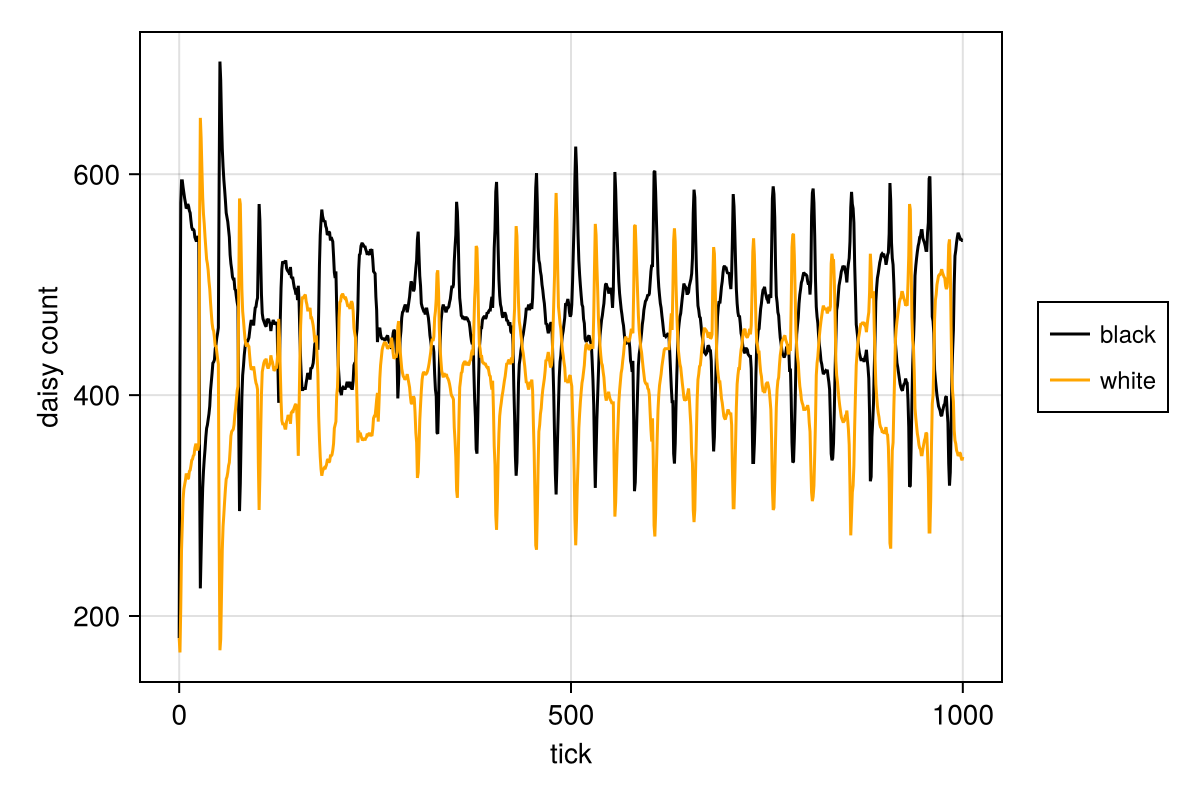

In [7]:
black(a) = a.breed == :black
white(a) = a.breed == :white
adata = [(black, count), (white, count)]

model2 = daisyworld(; solar_luminosity = 1.0)

agent_df, model_df = run!(model2, 1000; adata)
figure_count = Figure(size = (600, 400));

ax = figure_count[1, 1] = Axis(figure_count, xlabel = "tick", ylabel = "daisy count")
blackl = lines!(ax, agent_df[!, :time], agent_df[!, :count_black],
    color = :black)
whitel = lines!(ax, agent_df[!, :time], agent_df[!, :count_white],
    color = :orange)
Legend(figure_count[1, 2], [blackl, whitel], ["black", "white"], labelsize = 12)
figure_count

## Динамика модели (ramp-сценарий)

Построим комплексный график изменения числа маргариток, температуры
и светимости в зависимости от модельного времени.
В ramp-сценарии светимость увеличивается в период 200–400 тиков,
а затем уменьшается в период 500–750 тиков.

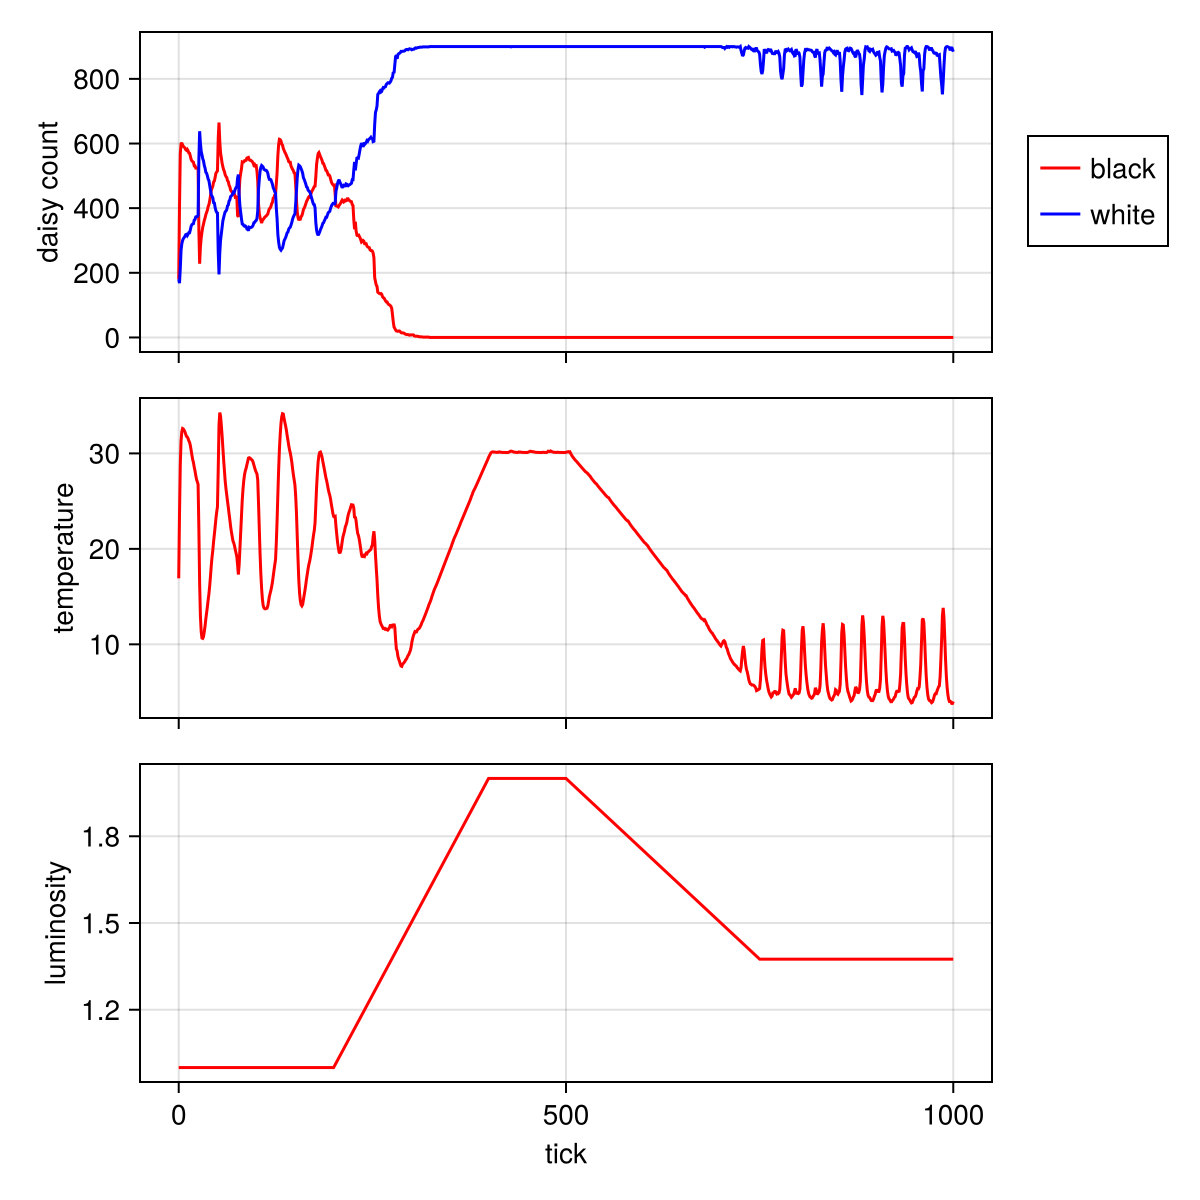

In [8]:
model3 = daisyworld(solar_luminosity = 1.0, scenario = :ramp)

temperature(model) = StatsBase.mean(model.temperature)
mdata = [temperature, :solar_luminosity]

agent_df3, model_df3 = run!(model3, 1000; adata = adata, mdata = mdata)

figure_lum = CairoMakie.Figure(size = (600, 600));
ax1 = figure_lum[1, 1] = Axis(figure_lum, ylabel = "daisy count")
blackl3 = lines!(ax1, agent_df3[!, :time], agent_df3[!, :count_black],
    color = :red)
whitel3 = lines!(ax1, agent_df3[!, :time], agent_df3[!, :count_white],
    color = :blue)
figure_lum[1, 2] = Legend(figure_lum, [blackl3, whitel3], ["black", "white"])

ax2 = figure_lum[2, 1] = Axis(figure_lum, ylabel = "temperature")
ax3 = figure_lum[3, 1] = Axis(figure_lum, xlabel = "tick", ylabel = "luminosity")
lines!(ax2, model_df3[!, :time], model_df3[!, :temperature], color = :red)
lines!(ax3, model_df3[!, :time], model_df3[!, :solar_luminosity], color = :red)
for ax in (ax1, ax2); ax.xticklabelsvisible = false; end
figure_lum

## Выводы

Модель Daisyworld демонстрирует:

1. **Саморегуляция**: маргаритки поддерживают температуру планеты
   в благоприятном диапазоне за счёт обратной связи через альбедо.
2. **Эмерджентное поведение**: глобальная стабилизация температуры
   возникает из локальных взаимодействий агентов.
3. **Устойчивость**: при умеренных возмущениях светимости система
   восстанавливает температурный баланс.
4. **Пределы устойчивости**: при слишком сильном воздействии
   маргаритки не могут компенсировать изменения и вымирают.